# import libraries

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from datasist.structdata import detect_outliers
## To Ignore Warnings 
from warnings import filterwarnings
filterwarnings('ignore')
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVR
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBRegressor
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.metrics import r2_score,mean_squared_error,make_scorer
from sklearn.feature_selection import SequentialFeatureSelector, SelectKBest, f_regression,RFE,SelectFromModel
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
import joblib as jb

# exploration data and contact csv files 

In [2]:
df=pd.read_csv('sample_submission.csv')
df_train=pd.read_csv('train.csv')
df_test=pd.read_csv('test.csv')

In [3]:
df['Response'].value_counts()

0    127037
Name: Response, dtype: int64

In [4]:
df_train['Response'].value_counts()

0    334399
1     46710
Name: Response, dtype: int64

In [5]:
df

,id,Response
0,381110,0
1,381111,0
2,381112,0
3,381113,0
4,381114,0
...,...,...
127032,508142,0
127033,508143,0
127034,508144,0
127035,508145,0


In [6]:
df_test

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage
0,381110,Male,25,1,11.0,1,< 1 Year,No,35786.0,152.0,53
1,381111,Male,40,1,28.0,0,1-2 Year,Yes,33762.0,7.0,111
2,381112,Male,47,1,28.0,0,1-2 Year,Yes,40050.0,124.0,199
3,381113,Male,24,1,27.0,1,< 1 Year,Yes,37356.0,152.0,187
4,381114,Male,27,1,28.0,1,< 1 Year,No,59097.0,152.0,297
...,...,...,...,...,...,...,...,...,...,...,...
127032,508142,Female,26,1,37.0,1,< 1 Year,No,30867.0,152.0,56
127033,508143,Female,38,1,28.0,0,1-2 Year,Yes,28700.0,122.0,165
127034,508144,Male,21,1,46.0,1,< 1 Year,No,29802.0,152.0,74
127035,508145,Male,71,1,28.0,1,1-2 Year,No,62875.0,26.0,265


In [7]:
df_test=pd.merge(left=df_test,right=df,on='id')

In [8]:
df_test

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,381110,Male,25,1,11.0,1,< 1 Year,No,35786.0,152.0,53,0
1,381111,Male,40,1,28.0,0,1-2 Year,Yes,33762.0,7.0,111,0
2,381112,Male,47,1,28.0,0,1-2 Year,Yes,40050.0,124.0,199,0
3,381113,Male,24,1,27.0,1,< 1 Year,Yes,37356.0,152.0,187,0
4,381114,Male,27,1,28.0,1,< 1 Year,No,59097.0,152.0,297,0
...,...,...,...,...,...,...,...,...,...,...,...,...
127032,508142,Female,26,1,37.0,1,< 1 Year,No,30867.0,152.0,56,0
127033,508143,Female,38,1,28.0,0,1-2 Year,Yes,28700.0,122.0,165,0
127034,508144,Male,21,1,46.0,1,< 1 Year,No,29802.0,152.0,74,0
127035,508145,Male,71,1,28.0,1,1-2 Year,No,62875.0,26.0,265,0


In [9]:
df=pd.concat([df_train,df_test],axis=0)

## Data Description
|Variable|Definition|
|---|---|
|id|Unique ID for the customer
|Gender|Gender of the customer
|Age|Age of the customer
|Driving_License|0 : Customer does not have DL
||1 : Customer already has DL
|Region_Code|Unique code for the region of the customer
|Previously_Insured|1 : Customer already has Vehicle Insurance
||0 : Customer doesn't have Vehicle Insurance
|Vehicle_Age|Age of the Vehicle
|Vehicle_Damage|1 : Customer got his/her vehicle damaged in the past
||0 : Customer didn't get his/her vehicle damaged in the past.
|Annual_Premium|The amount customer needs to pay as premium in the year
|Policy_Sales_Channel|Anonymized Code for the channel of outreaching to the customer
|Vintage|Number of Days, Customer has been associated with the company
|Response|1 : Customer is interested
||0 : Customer is not interested


In [10]:
df

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0
...,...,...,...,...,...,...,...,...,...,...,...,...
127032,508142,Female,26,1,37.0,1,< 1 Year,No,30867.0,152.0,56,0
127033,508143,Female,38,1,28.0,0,1-2 Year,Yes,28700.0,122.0,165,0
127034,508144,Male,21,1,46.0,1,< 1 Year,No,29802.0,152.0,74,0
127035,508145,Male,71,1,28.0,1,1-2 Year,No,62875.0,26.0,265,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 508146 entries, 0 to 127036
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    508146 non-null  int64  
 1   Gender                508146 non-null  object 
 2   Age                   508146 non-null  int64  
 3   Driving_License       508146 non-null  int64  
 4   Region_Code           508146 non-null  float64
 5   Previously_Insured    508146 non-null  int64  
 6   Vehicle_Age           508146 non-null  object 
 7   Vehicle_Damage        508146 non-null  object 
 8   Annual_Premium        508146 non-null  float64
 9   Policy_Sales_Channel  508146 non-null  float64
 10  Vintage               508146 non-null  int64  
 11  Response              508146 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 50.4+ MB


# show, is null and duplicated

In [12]:
df.duplicated().sum()

0

In [13]:
df['Response'].value_counts()

0    461436
1     46710
Name: Response, dtype: int64

In [14]:
df.describe()

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,508146.000000,508146.000000,508146.000000,508146.000000,508146.000000,508146.000000,508146.000000,508146.000000,508146.000000
mean,254073.500000,38.808413,0.997936,26.406572,0.458667,30554.453041,111.975838,154.340123,0.091922
std,146689.259281,15.500179,0.045388,13.224921,0.498289,17146.574625,54.246027,83.668793,0.288917
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,127037.250000,25.000000,1.000000,15.000000,0.000000,24381.000000,26.000000,82.000000,0.000000
50%,254073.500000,36.000000,1.000000,28.000000,0.000000,31661.000000,133.000000,154.000000,0.000000
75%,381109.750000,49.000000,1.000000,35.000000,1.000000,39403.750000,152.000000,227.000000,0.000000
max,508146.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


In [15]:
df_numeric = df.select_dtypes(include=['number'])
df_numeric.corr()

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
id,1.000000,-0.000643,0.001362,0.001325,0.002557,0.001042,-0.002812,-0.000391,-0.138643
Age,-0.000643,1.000000,-0.079660,0.041649,-0.255582,0.067392,-0.577043,-0.000010,0.094979
Driving_License,0.001362,-0.079660,1.000000,-0.000202,0.014370,-0.012084,0.042862,-0.000850,0.008318
Region_Code,0.001325,0.041649,-0.000202,1.000000,-0.023991,-0.012012,-0.042223,-0.001568,0.008574
Previously_Insured,0.002557,-0.255582,0.014370,-0.023991,1.000000,0.004776,0.221334,0.001664,-0.290704
Annual_Premium,0.001042,0.067392,-0.012084,-0.012012,0.004776,1.000000,-0.114035,-0.000855,0.019477
Policy_Sales_Channel,-0.002812,-0.577043,0.042862,-0.042223,0.221334,-0.114035,1.000000,-0.000814,-0.117930
Vintage,-0.000391,-0.000010,-0.000850,-0.001568,0.001664,-0.000855,-0.000814,1.000000,-0.000867
Response,-0.138643,0.094979,0.008318,0.008574,-0.290704,0.019477,-0.117930,-0.000867,1.000000


In [16]:
del df['id']

<Axes: xlabel='Age', ylabel='Count'>

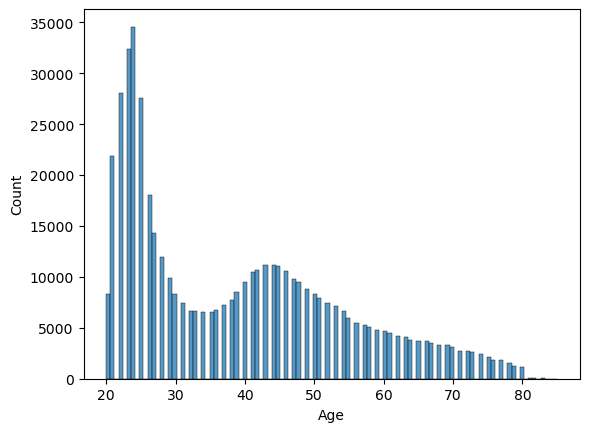

In [17]:
sns.histplot(df,x='Age')

<Axes: xlabel='Driving_License', ylabel='count'>

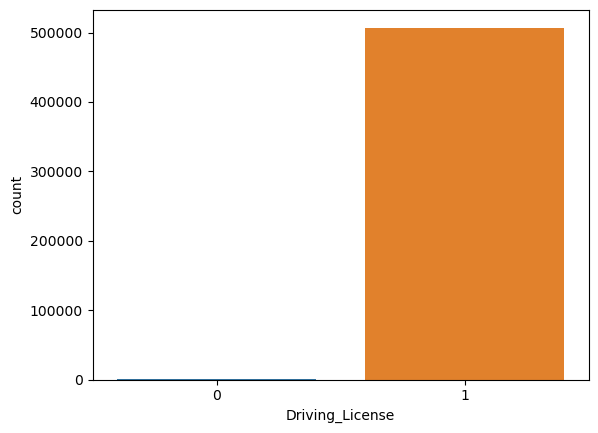

In [18]:
sns.countplot(df,x='Driving_License')

<Axes: xlabel='Previously_Insured', ylabel='count'>

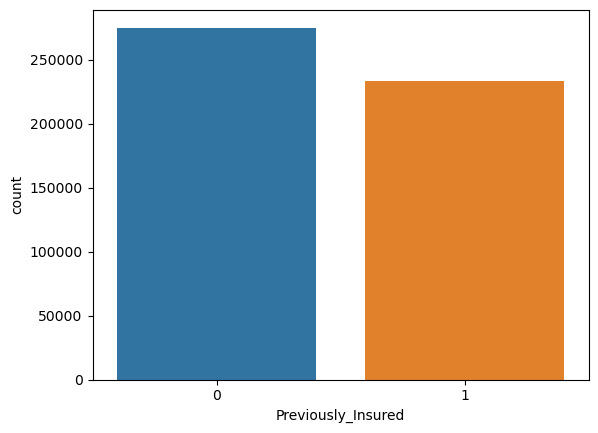

In [19]:
sns.countplot(df,x='Previously_Insured')

In [20]:
df['Region_Code'].value_counts()

28.0    141937
8.0      44900
46.0     26357
41.0     24400
15.0     17750
30.0     16276
29.0     14843
50.0     13657
3.0      12349
11.0     12328
36.0     11696
33.0     10307
47.0      9942
35.0      9309
6.0       8351
45.0      7543
37.0      7343
18.0      6903
48.0      6274
14.0      6249
39.0      6138
10.0      5847
21.0      5671
2.0       5398
13.0      5396
7.0       4313
12.0      4235
9.0       4084
32.0      3745
27.0      3711
43.0      3508
26.0      3461
17.0      3455
25.0      3352
24.0      3263
16.0      2727
0.0       2699
38.0      2677
31.0      2635
23.0      2596
20.0      2528
49.0      2388
4.0       2379
34.0      2190
19.0      2059
22.0      1729
40.0      1708
5.0       1698
1.0       1363
44.0      1064
42.0       787
52.0       357
51.0       271
Name: Region_Code, dtype: int64

<Axes: xlabel='Previously_Insured', ylabel='count'>

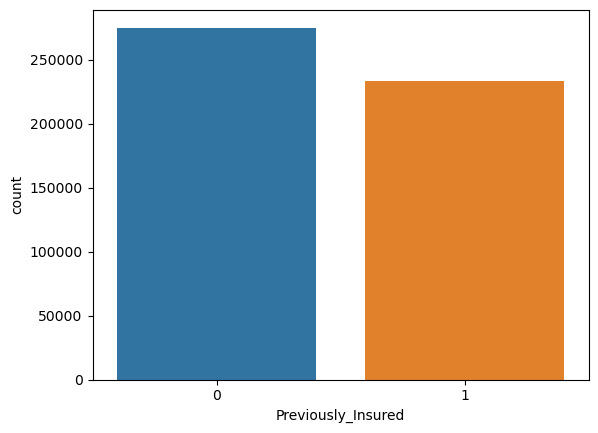

In [21]:
sns.countplot(df,x='Previously_Insured')

<Axes: xlabel='Vehicle_Age', ylabel='count'>

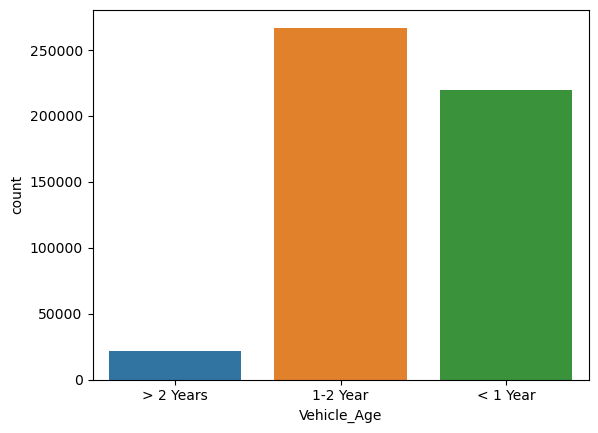

In [22]:
sns.countplot(df,x='Vehicle_Age')

<Axes: xlabel='Vehicle_Damage', ylabel='count'>

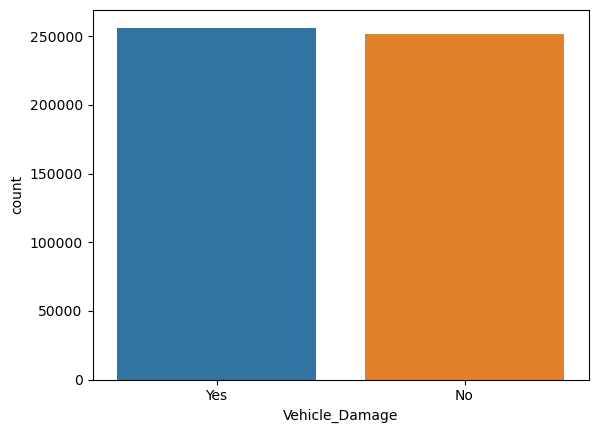

In [23]:
sns.countplot(df,x='Vehicle_Damage')

<Axes: xlabel='Annual_Premium', ylabel='Count'>

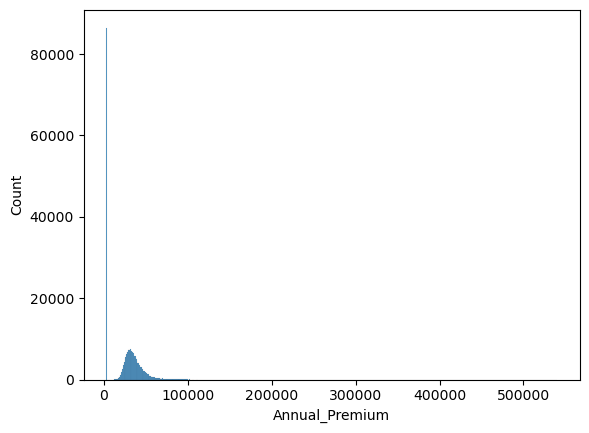

In [24]:
sns.histplot(df,x="Annual_Premium")

#### there are outliers in annual_preium i think it's more money to payed while some of vehicle isnot damage  

<Axes: xlabel='Annual_Premium'>

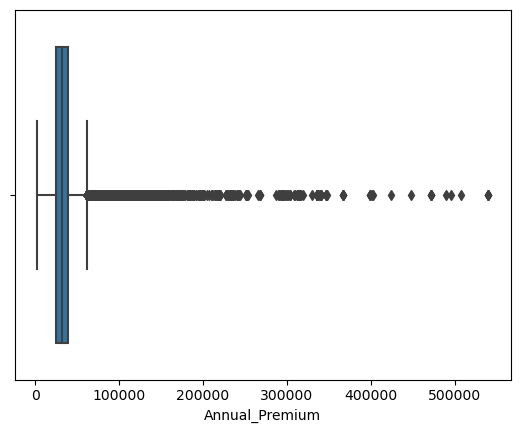

In [25]:
sns.boxplot(df,x="Annual_Premium")

In [26]:
df['Policy_Sales_Channel'].value_counts()

152.0    179523
26.0     106594
124.0     98299
160.0     29090
156.0     14313
          ...  
41.0          1
84.0          1
144.0         1
149.0         1
142.0         1
Name: Policy_Sales_Channel, Length: 157, dtype: int64

<Axes: xlabel='Vintage', ylabel='Count'>

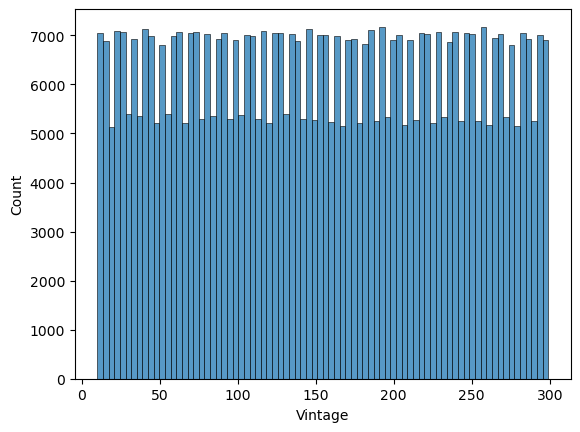

In [27]:
sns.histplot(df,x='Vintage')

In [28]:
#ok now i will detect outliers from annual_premium
pd.options.mode.chained_assignment = None
outliers_columns=detect_outliers(df,n=0,features=['Annual_Premium'])
median_columns=df['Annual_Premium'].median()
df['Annual_Premium'].iloc[outliers_columns]=median_columns

<Axes: xlabel='Annual_Premium'>

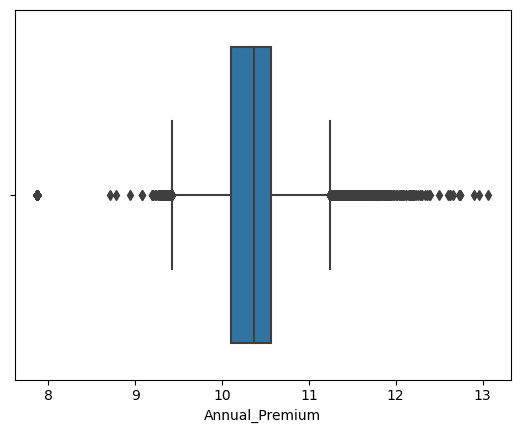

In [29]:
sns.boxplot(df,x=np.log(df["Annual_Premium"]))


<Axes: xlabel='Annual_Premium', ylabel='Count'>

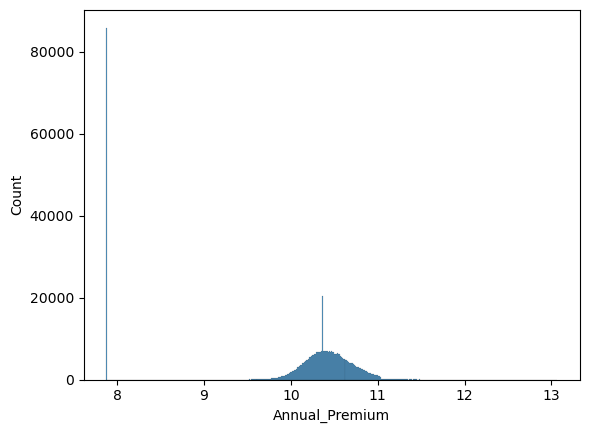

In [30]:
sns.histplot(df,x=np.log(df["Annual_Premium"]))

In [31]:
convert_Vehicle={'Yes':1,'No':0}

In [32]:
df['Vehicle_Damage']=df['Vehicle_Damage'].map(convert_Vehicle)

In [33]:
df

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,Male,44,1,28.0,0,> 2 Years,1,40454.0,26.0,217,1
1,Male,76,1,3.0,0,1-2 Year,0,33536.0,26.0,183,0
2,Male,47,1,28.0,0,> 2 Years,1,38294.0,26.0,27,1
3,Male,21,1,11.0,1,< 1 Year,0,28619.0,152.0,203,0
4,Female,29,1,41.0,1,< 1 Year,0,27496.0,152.0,39,0
...,...,...,...,...,...,...,...,...,...,...,...
127032,Female,26,1,37.0,1,< 1 Year,0,30867.0,152.0,56,0
127033,Female,38,1,28.0,0,1-2 Year,1,28700.0,122.0,165,0
127034,Male,21,1,46.0,1,< 1 Year,0,29802.0,152.0,74,0
127035,Male,71,1,28.0,1,1-2 Year,0,62875.0,26.0,265,0


In [34]:
ml_df = df.copy()

In [35]:
ml_df

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,Male,44,1,28.0,0,> 2 Years,1,40454.0,26.0,217,1
1,Male,76,1,3.0,0,1-2 Year,0,33536.0,26.0,183,0
2,Male,47,1,28.0,0,> 2 Years,1,38294.0,26.0,27,1
3,Male,21,1,11.0,1,< 1 Year,0,28619.0,152.0,203,0
4,Female,29,1,41.0,1,< 1 Year,0,27496.0,152.0,39,0
...,...,...,...,...,...,...,...,...,...,...,...
127032,Female,26,1,37.0,1,< 1 Year,0,30867.0,152.0,56,0
127033,Female,38,1,28.0,0,1-2 Year,1,28700.0,122.0,165,0
127034,Male,21,1,46.0,1,< 1 Year,0,29802.0,152.0,74,0
127035,Male,71,1,28.0,1,1-2 Year,0,62875.0,26.0,265,0


In [36]:
def count(x):
    if x==0:
        return 1
    else:
        return 0

In [37]:
df['not have license']=df['Driving_License'].map(count)

In [38]:
df.describe()

,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response,not have license
count,508146.000000,508146.000000,508146.000000,508146.000000,508146.000000,508146.000000,508146.000000,508146.000000,508146.000000,508146.000000
mean,38.808413,0.997936,26.406572,0.458667,0.504280,29648.571879,111.975838,154.340123,0.091922,0.002064
std,15.500179,0.045388,13.224921,0.498289,0.499982,15147.884598,54.246027,83.668793,0.288917,0.045388
min,20.000000,0.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000,0.000000
25%,25.000000,1.000000,15.000000,0.000000,0.000000,24451.000000,26.000000,82.000000,0.000000,0.000000
50%,36.000000,1.000000,28.000000,0.000000,1.000000,31661.000000,133.000000,154.000000,0.000000,0.000000
75%,49.000000,1.000000,35.000000,1.000000,1.000000,38538.000000,152.000000,227.000000,0.000000,0.000000
max,85.000000,1.000000,52.000000,1.000000,1.000000,472042.000000,163.000000,299.000000,1.000000,1.000000


# feature engineering

In [39]:
def convert (x):
    if x<=24451.0:
        return 'low'
    elif 24451.0<x<=31661.0:
        return 'medium'
    else:
        return 'high'

In [40]:
df['Annual_Premium']=df['Annual_Premium'].apply(convert)

In [41]:
df

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response,not have license
0,Male,44,1,28.0,0,> 2 Years,1,high,26.0,217,1,0
1,Male,76,1,3.0,0,1-2 Year,0,high,26.0,183,0,0
2,Male,47,1,28.0,0,> 2 Years,1,high,26.0,27,1,0
3,Male,21,1,11.0,1,< 1 Year,0,medium,152.0,203,0,0
4,Female,29,1,41.0,1,< 1 Year,0,medium,152.0,39,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
127032,Female,26,1,37.0,1,< 1 Year,0,medium,152.0,56,0,0
127033,Female,38,1,28.0,0,1-2 Year,1,medium,122.0,165,0,0
127034,Male,21,1,46.0,1,< 1 Year,0,medium,152.0,74,0,0
127035,Male,71,1,28.0,1,1-2 Year,0,high,26.0,265,0,0


# Business questions

#### what is more gender intrest about insured

In [42]:
z=df.loc[df['Response'] == 1].groupby(['Gender'])['Response'].sum().reset_index().sort_values(by='Response',ascending=False)

Text(0.5, 1.0, 'Responses by Gender')

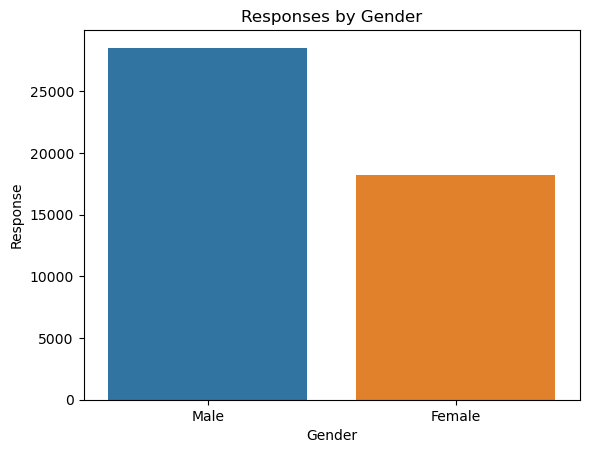

In [43]:
sns.barplot(x='Gender', y='Response', data=z)

# Add labels and title
plt.xlabel('Gender')
plt.ylabel('Response')
plt.title('Responses by Gender')

#### top ten age is intresting about  insured

In [44]:
z=df.loc[df['Response'] == 1].groupby(['Age'])['Response'].sum().reset_index().sort_values(by='Response',ascending=False).head(10)

Text(0.5, 1.0, 'Responses by top ten age')

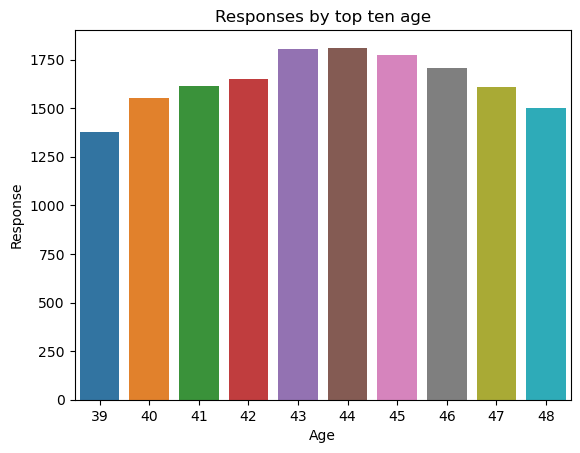

In [45]:
sns.barplot(x='Age', y='Response', data=z)

# Add labels and title
plt.xlabel('Age')
plt.ylabel('Response')
plt.title('Responses by top ten age')

#### top ten of age that Vehicle_Damage

In [46]:
z=df.loc[df['Vehicle_Damage'] == 1].groupby(['Age'])['Vehicle_Damage'].sum().reset_index().sort_values(by='Vehicle_Damage',ascending=False).head(10)

Text(0.5, 1.0, 'Vehicle_Damage with age')

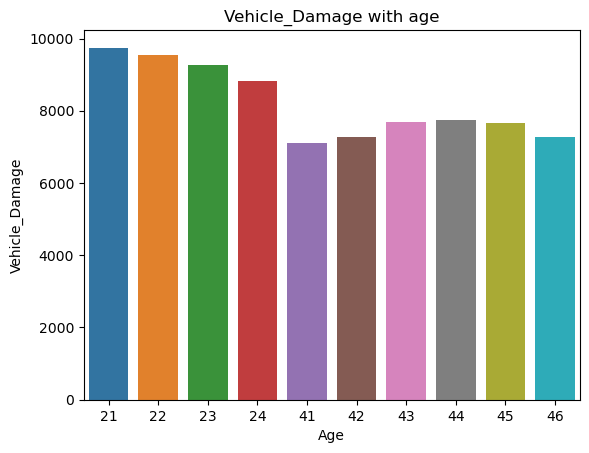

In [47]:
sns.barplot(x='Age', y='Vehicle_Damage', data=z)

# Add labels and title
plt.xlabel('Age')
plt.ylabel('Vehicle_Damage')
plt.title('Vehicle_Damage with age')

#### The top ten ages of people who do not have a driver’s license

In [48]:
z=df.loc[df['not have license'] == 1].groupby(['Age'])['not have license'].sum().reset_index().sort_values(by='not have license',ascending=False).head(10)

Text(0.5, 1.0, 'not have license with age')

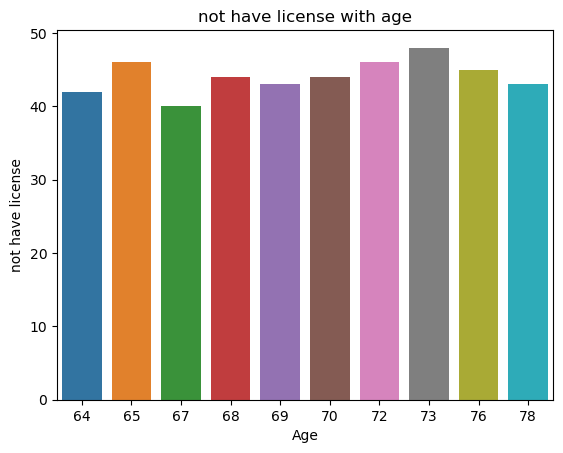

In [49]:
sns.barplot(x='Age', y='not have license', data=z)

# Add labels and title
plt.xlabel('Age')
plt.ylabel('not have license')
plt.title('not have license with age')

In [50]:
z=df.loc[df['Vehicle_Damage']==1].groupby(['Vehicle_Age'])['Vehicle_Damage'].sum().reset_index()

Text(0.5, 1.0, 'Vehicle_Damage with Vehicle_Age')

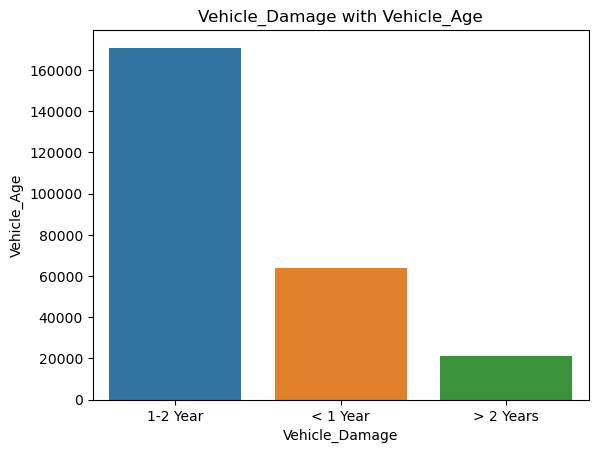

In [51]:
sns.barplot(x='Vehicle_Age', y='Vehicle_Damage', data=z)

# Add labels and title
plt.xlabel('Vehicle_Damage')
plt.ylabel('Vehicle_Age')
plt.title('Vehicle_Damage with Vehicle_Age')

#### The ten most Region_Code where Vehicle_Damage

In [52]:
z=df.loc[df['Vehicle_Damage']==1].groupby(['Region_Code'])['Vehicle_Damage'].sum().reset_index().sort_values(by='Vehicle_Damage',ascending=False).head(10)

Text(0.5, 1.0, 'Vehicle_Damage where Region_Code')

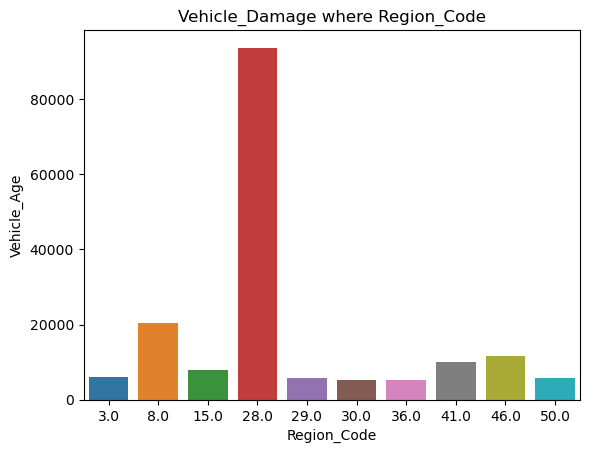

In [53]:
sns.barplot(x='Region_Code', y='Vehicle_Damage', data=z)
# Add labels and title
plt.xlabel('Region_Code')
plt.ylabel('Vehicle_Age')
plt.title('Vehicle_Damage where Region_Code')

In [54]:
df

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response,not have license
0,Male,44,1,28.0,0,> 2 Years,1,high,26.0,217,1,0
1,Male,76,1,3.0,0,1-2 Year,0,high,26.0,183,0,0
2,Male,47,1,28.0,0,> 2 Years,1,high,26.0,27,1,0
3,Male,21,1,11.0,1,< 1 Year,0,medium,152.0,203,0,0
4,Female,29,1,41.0,1,< 1 Year,0,medium,152.0,39,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
127032,Female,26,1,37.0,1,< 1 Year,0,medium,152.0,56,0,0
127033,Female,38,1,28.0,0,1-2 Year,1,medium,122.0,165,0,0
127034,Male,21,1,46.0,1,< 1 Year,0,medium,152.0,74,0,0
127035,Male,71,1,28.0,1,1-2 Year,0,high,26.0,265,0,0


In [55]:
z=df.loc[df['Response']==1].groupby(['Annual_Premium'])['Response'].sum().reset_index().sort_values(by='Response',ascending=False).head(10)

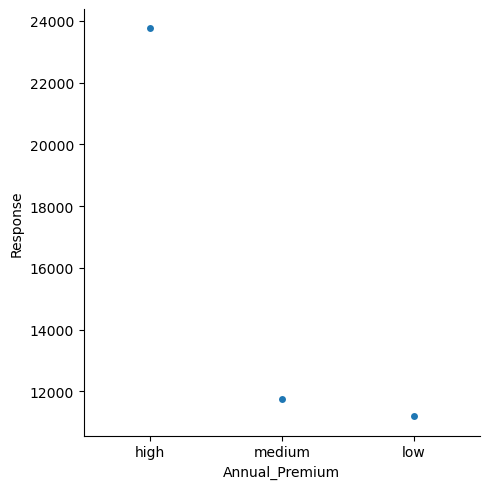

In [56]:
sns.catplot(z,x='Annual_Premium',y='Response')

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 508146 entries, 0 to 127036
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Gender                508146 non-null  object 
 1   Age                   508146 non-null  int64  
 2   Driving_License       508146 non-null  int64  
 3   Region_Code           508146 non-null  float64
 4   Previously_Insured    508146 non-null  int64  
 5   Vehicle_Age           508146 non-null  object 
 6   Vehicle_Damage        508146 non-null  int64  
 7   Annual_Premium        508146 non-null  object 
 8   Policy_Sales_Channel  508146 non-null  float64
 9   Vintage               508146 non-null  int64  
 10  Response              508146 non-null  int64  
 11  not have license      508146 non-null  int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 50.4+ MB


In [58]:
del df['not have license']

<Axes: >

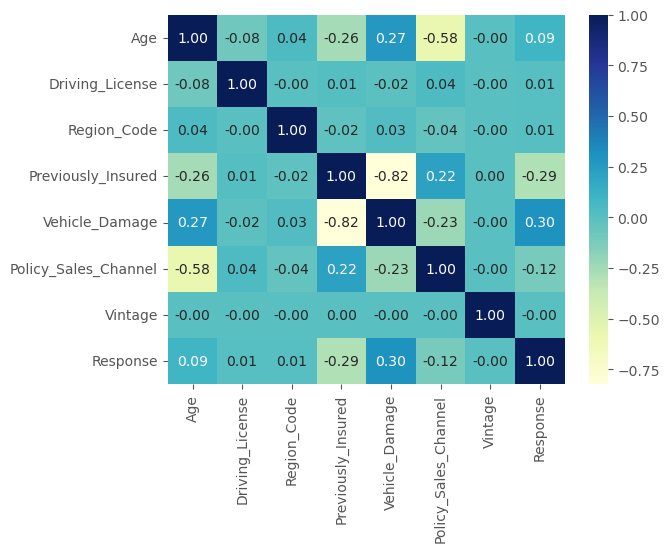

In [59]:
plt.style.use('ggplot')
sns.heatmap(df.corr(numeric_only=True),annot = True, cmap= 'YlGnBu', fmt= '.2f')

In [60]:
df.describe()

,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Damage,Policy_Sales_Channel,Vintage,Response
count,508146.000000,508146.000000,508146.000000,508146.000000,508146.000000,508146.000000,508146.000000,508146.000000
mean,38.808413,0.997936,26.406572,0.458667,0.504280,111.975838,154.340123,0.091922
std,15.500179,0.045388,13.224921,0.498289,0.499982,54.246027,83.668793,0.288917
min,20.000000,0.000000,0.000000,0.000000,0.000000,1.000000,10.000000,0.000000
25%,25.000000,1.000000,15.000000,0.000000,0.000000,26.000000,82.000000,0.000000
50%,36.000000,1.000000,28.000000,0.000000,1.000000,133.000000,154.000000,0.000000
75%,49.000000,1.000000,35.000000,1.000000,1.000000,152.000000,227.000000,0.000000
max,85.000000,1.000000,52.000000,1.000000,1.000000,163.000000,299.000000,1.000000


# machine learning

In [61]:
conv_gen={"Male":1,'Female':0}
conv_veh={'> 2 Years':3,'1-2 Year':2,'< 1 Year':1}

In [62]:
ml_df['Gender']=ml_df['Gender'].map(conv_gen)
ml_df['Vehicle_Age']=ml_df['Vehicle_Age'].map(conv_veh)

In [63]:
X=ml_df.drop('Response',axis=1)
Y=ml_df['Response']

In [64]:
## scaler
scalers =[
    ('STD scaler',StandardScaler()),
    ('minMax',MinMaxScaler()),
    ('robus',RobustScaler())
]

In [65]:
from xgboost import XGBClassifier

In [66]:
ml_df.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,44,1,28.0,0,3,1,40454.0,26.0,217,1
1,1,76,1,3.0,0,2,0,33536.0,26.0,183,0
2,1,47,1,28.0,0,3,1,38294.0,26.0,27,1
3,1,21,1,11.0,1,1,0,28619.0,152.0,203,0
4,0,29,1,41.0,1,1,0,27496.0,152.0,39,0


In [67]:
## Models 
models = []
models.append(('LR' , LogisticRegression()))
models.append(('NB' , MultinomialNB()))
models.append(('DT' , DecisionTreeClassifier()))
models.append(('RF' , RandomForestClassifier()))
models.append(('XGB' , XGBClassifier()))
models.append(('Ada' , AdaBoostClassifier()))

In [68]:
import imblearn
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler()
X_resampled, y_resampled = rus.fit_resample(X, Y)
print(Y.value_counts())
print()
print(y_resampled.value_counts())

0    461436
1     46710
Name: Response, dtype: int64

0    46710
1    46710
Name: Response, dtype: int64


In [69]:
for model in models:

    steps = []
    steps.append(('sclr' , MinMaxScaler()) if model[0] == 'NB'  else ('sclr' , StandardScaler()))
    steps.append(model)

    PL = Pipeline(steps=steps)

    scores = cross_validate(estimator=PL , X = X_resampled , y = y_resampled , return_train_score=True , scoring='accuracy' , cv = 5,n_jobs=-1)

    print(model[0])
    print('train acc : '.title() , scores['train_score'].mean() )
    print('test acc : '.title() , scores['test_score'].mean() )
    print('-'*30)

LR
Train Acc :  0.7740633697281096
Test Acc :  0.7741061871119674
------------------------------
NB
Train Acc :  0.7625561978163133
Test Acc :  0.7625347891243845
------------------------------
DT
Train Acc :  0.999909013059302
Test Acc :  0.7032755298651252
------------------------------
RF
Train Acc :  0.9999009847998288
Test Acc :  0.7721044744166132
------------------------------
XGB
Train Acc :  0.8158558124598587
Test Acc :  0.7859880111325198
------------------------------
Ada
Train Acc :  0.7877488760436737
Test Acc :  0.7865125240847783
------------------------------



* ok the best algorithm is AdaBoostClassifier
* Preparing Data to go through feature selector for AdaBoostClassifier
* Feature Selector (Sequential Selector Forward Elminating)

In [70]:
steps = []

steps.append(('sclr' , StandardScaler()))
steps.append(('Ada',AdaBoostClassifier()))
PL = Pipeline(steps=steps)

In [71]:
PL

Pipeline(steps=[('sclr', StandardScaler()), ('Ada', AdaBoostClassifier())])

In [72]:
# feature selector for XGBClassifier forward
Forward = SequentialFeatureSelector(PL  ,
                                    n_features_to_select="auto" ,
                                    tol = None ,
                                    direction="forward")
Forward

SequentialFeatureSelector(estimator=Pipeline(steps=[('sclr', StandardScaler()),
                                                    ('Ada',
                                                     AdaBoostClassifier())]),
                          n_features_to_select='auto')

In [73]:
Forward.fit(X_resampled,y_resampled)

SequentialFeatureSelector(estimator=Pipeline(steps=[('sclr', StandardScaler()),
                                                    ('Ada',
                                                     AdaBoostClassifier())]),
                          n_features_to_select='auto')

In [74]:
selectedFeatures_forw  = pd.DataFrame(Forward.transform(X_resampled) , columns=Forward.get_feature_names_out())
selectedFeatures_forw

,Region_Code,Previously_Insured,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel
0,50.0,1.0,0.0,34555.0,8.0
1,30.0,0.0,0.0,2630.0,152.0
2,8.0,0.0,1.0,45146.0,26.0
3,28.0,0.0,1.0,40222.0,122.0
4,1.0,0.0,1.0,2630.0,156.0
...,...,...,...,...,...
93415,46.0,0.0,1.0,27508.0,26.0
93416,28.0,0.0,1.0,37377.0,124.0
93417,28.0,0.0,1.0,34741.0,124.0
93418,28.0,0.0,1.0,43875.0,26.0


In [75]:
# feature selector for XGBClassifier backward
BackElim = SequentialFeatureSelector(estimator=PL ,
                                     n_features_to_select = 'auto',
                                     tol = None ,
                                     direction="backward")
BackElim ## try to change regressor with any other one 

SequentialFeatureSelector(direction='backward',
                          estimator=Pipeline(steps=[('sclr', StandardScaler()),
                                                    ('Ada',
                                                     AdaBoostClassifier())]),
                          n_features_to_select='auto')

In [76]:
BackElim.fit(X_resampled,y_resampled)

SequentialFeatureSelector(direction='backward',
                          estimator=Pipeline(steps=[('sclr', StandardScaler()),
                                                    ('Ada',
                                                     AdaBoostClassifier())]),
                          n_features_to_select='auto')

In [77]:
selectedFeatures_back  = pd.DataFrame(BackElim.transform(X_resampled) , columns=BackElim.get_feature_names_out())
selectedFeatures_back

,Age,Previously_Insured,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel
0,79.0,1.0,0.0,34555.0,8.0
1,44.0,0.0,0.0,2630.0,152.0
2,46.0,0.0,1.0,45146.0,26.0
3,52.0,0.0,1.0,40222.0,122.0
4,59.0,0.0,1.0,2630.0,156.0
...,...,...,...,...,...
93415,40.0,0.0,1.0,27508.0,26.0
93416,41.0,0.0,1.0,37377.0,124.0
93417,46.0,0.0,1.0,34741.0,124.0
93418,61.0,0.0,1.0,43875.0,26.0


<Axes: >

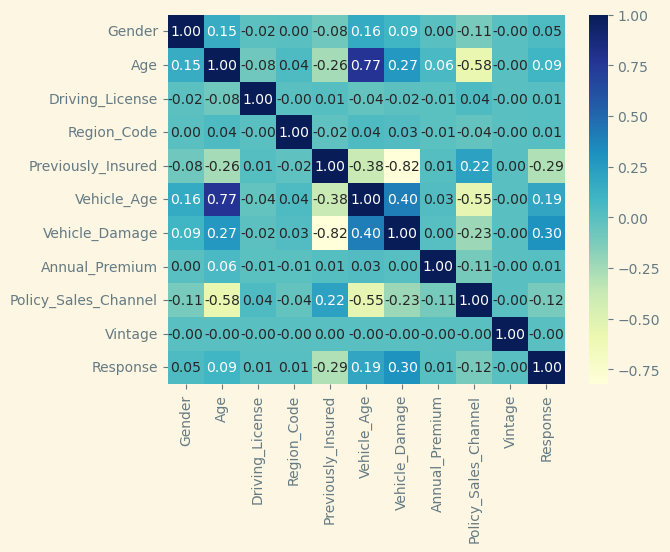

In [78]:
plt.style.use('Solarize_Light2')
sns.heatmap(ml_df.corr(numeric_only=True),annot = True, cmap= 'YlGnBu', fmt= '.2f')

In [79]:
model = AdaBoostClassifier()
selector = SelectFromModel(model)
selector

SelectFromModel(estimator=AdaBoostClassifier())

In [80]:
selector.fit( X_resampled, y_resampled)

SelectFromModel(estimator=AdaBoostClassifier())

In [81]:
embFeatures = pd.DataFrame(selector.fit_transform(X_resampled , y_resampled) , columns=selector.get_feature_names_out())
embFeatures

,Age,Region_Code,Policy_Sales_Channel
0,79.0,50.0,8.0
1,44.0,30.0,152.0
2,46.0,8.0,26.0
3,52.0,28.0,122.0
4,59.0,1.0,156.0
...,...,...,...
93415,40.0,46.0,26.0
93416,41.0,28.0,124.0
93417,46.0,28.0,124.0
93418,61.0,28.0,26.0


In [82]:
## Checking model accuracy

  # selector_result_back and y_resampled are your input data and targets
cv_results_back = cross_validate(X=selectedFeatures_back, y=y_resampled, estimator=PL, scoring='accuracy', cv=5, return_train_score=True, n_jobs=-1)


# Access the results
print("test :", cv_results_back['test_score'].mean())
print("train:", cv_results_back['train_score'].mean())

test : 0.7850139156497539
train: 0.7856267394562192


In [83]:
cv_results_emb = cross_validate(X=embFeatures, y=y_resampled, estimator=PL, scoring='accuracy', cv=5, return_train_score=True, n_jobs=-1)


# Access the results
print("test :", cv_results_emb['test_score'].mean())
print("train:", cv_results_emb['train_score'].mean())

test : 0.6951188182402056
train: 0.6961464354527938


In [84]:
## Checking model accuracy

  # X and y are your input data and targets
cv_results_forw = cross_validate(X=selectedFeatures_forw, y=y_resampled, estimator=PL, scoring='accuracy', cv=5, return_train_score=True, n_jobs=-1)


# Access the results
print("test :", cv_results_forw['test_score'].mean())
print("train:", cv_results_forw['train_score'].mean())

test : 0.7846713765788911
train: 0.7848961678441448


In [85]:
# Define your parameter grid for GridSearchCV
param_grid = {
              'Ada__n_estimators':[10,50,250,1000],
              'Ada__learning_rate':[0.01,0.1,1],
             }

In [86]:
# Create the GridSearchCV object
grid_search = GridSearchCV(estimator=PL, param_grid=param_grid, scoring='accuracy', cv=5, return_train_score=True,n_jobs=-1)

# Fit the GridSearchCV on your data
grid_search.fit(X_resampled, y_resampled)  # X and y are your input data and targets

best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Score:", best_score)

Best Parameters: {'Ada__learning_rate': 1, 'Ada__n_estimators': 1000}
Best Score: 0.7884178976664525


In [87]:
# Get the mean test score and mean train score for the best estimator
mean_test_score = grid_search.cv_results_['mean_test_score'][grid_search.best_index_]
mean_train_score = grid_search.cv_results_['mean_train_score'][grid_search.best_index_]

print("Mean Test Score:", mean_test_score)
print("Mean Train Score:", mean_train_score)

Mean Test Score: 0.7884178976664525
Mean Train Score: 0.7906604581460073


In [88]:
final_model=grid_search.best_estimator_

## Saving important objects For Deploying


In [89]:
final_model

Pipeline(steps=[('sclr', StandardScaler()),
                ('Ada',
                 AdaBoostClassifier(learning_rate=1, n_estimators=1000))])

In [90]:

jb.dump(final_model,"Model_Final.pkl")
jb.dump(X_resampled.columns,"Inputs_Final.pkl")

['Inputs_Final.pkl']

In [92]:
Model= jb.load("Model_Final.pkl")
Inputs= jb.load("Inputs_Final.pkl")

In [93]:
Inputs

Index(['Gender', 'Age', 'Driving_License', 'Region_Code', 'Previously_Insured',
       'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel', 'Vintage'],
      dtype='object')

In [94]:
Model

Pipeline(steps=[('sclr', StandardScaler()),
                ('Ada',
                 AdaBoostClassifier(learning_rate=1, n_estimators=1000))])

In [95]:
def prediction(Gender, Age, Driving_License,Region_Code, Previously_Insured, Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage):
    test_df=pd.DataFrame(columns=Inputs)
    test_df.at[0,'Gender']=gender_map(Gender) 
    test_df.at[0,'Age']= Age
    test_df.at[0,'Driving_License']= Driving_License_map(Driving_License)
    test_df.at[0,'Region_Code']= Region_Code
    test_df.at[0,'Previously_Insured']= Previously_Insured_map(Previously_Insured)
    test_df.at[0,'Vehicle_Age']= Vehicle_Age_map(Vehicle_Age)
    test_df.at[0,'Vehicle_Damage']= Vehicle_Damage_map(Vehicle_Damage)
    test_df.at[0,'Annual_Premium']= Annual_Premium
    test_df.at[0,'Policy_Sales_Channel']= Policy_Sales_Channel
    test_df.at[0,'Vintage']= Vintage
    result= Model.predict(test_df)
    return result[0]
def gender_map(x):
    gender={'Male':1,'Female':0}
    return gender[x]
def Driving_License_map(y):
    Driving_License={'yes':1,'no':0}
    return Driving_License[y]
def Previously_Insured_map(z):
    Previously_Insured={'yes':1,'no':0}
    return Previously_Insured[z]
def Vehicle_Age_map(a):
    Vehicle_Age={'more than 2 Years':3.0,'1-2 Year':2.0,'less than 1 Year':1.0}
    return Vehicle_Age[a]
def Vehicle_Damage_map(s):
    Vehicle_Damage={'yes':1,'no':0}
    return Vehicle_Damage[s]

In [96]:
print(prediction('Male', 22, 'yes',28.0, 'no','less than 1 Year' ,'yes','41343.0',26.0,236))

1


In [109]:
pip install --user requests


Note: you may need to restart the kernel to use updated packages.


In [98]:
#!pip install joblib

In [99]:
#pip install --upgrade joblib

In [100]:
#import sys;  print(sys.path)

In [104]:
import streamlit as st

In [105]:
%%writefile streamlit_app_final.py
import joblib as jb
import streamlit as st
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
Model= jb.load("Model_Final.pkl")
Inputs= jb.load("Inputs_Final.pkl")
def prediction(Gender, Age, Driving_License,Region_Code, Previously_Insured, Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage):
    test_df=pd.DataFrame(columns=Inputs)
    test_df.at[0,'Gender']=gender_map(Gender) 
    test_df.at[0,'Age']= Age
    test_df.at[0,'Driving_License']= Driving_License_map(Driving_License)
    test_df.at[0,'Region_Code']= Region_Code
    test_df.at[0,'Previously_Insured']= Previously_Insured_map(Previously_Insured)
    test_df.at[0,'Vehicle_Age']= Vehicle_Age_map(Vehicle_Age)
    test_df.at[0,'Vehicle_Damage']= Vehicle_Damage_map(Vehicle_Damage)
    test_df.at[0,'Annual_Premium']= Annual_Premium
    test_df.at[0,'Policy_Sales_Channel']= Policy_Sales_Channel
    test_df.at[0,'Vintage']= Vintage
    result= Model.predict(test_df)
    return result[0]
def gender_map(x):
    gender={'Male':1,'Female':0}
    return gender[x]
def Driving_License_map(y):
    Driving_License={'yes':1,'no':0}
    return Driving_License[y]
def Previously_Insured_map(z):
    Previously_Insured={'yes':1,'no':0}
    return Previously_Insured[z]
def Vehicle_Age_map(a):
    Vehicle_Age={'more than 2 Years':3.0,'1-2 Year':2.0,'less than 1 Year':1.0}
    return Vehicle_Age[a]
def Vehicle_Damage_map(s):
    Vehicle_Damage={'yes':1,'no':0}
    return Vehicle_Damage[s]
def main():
    ## Setting up the page title and icon
    st.set_page_config(page_icon = '🏠 🏥',page_title= 'Health Insurance Prediction')
     # Add a title in the middle of the page using Markdown and CSS
    st.markdown("<h1 style='text-align: center;text-decoration: underline;color:GoldenRod'>Vehicle_Insurance</h1>", unsafe_allow_html=True)
    Gender=st.radio('Select Gender',['Male', 'Female'])
    Age=st.slider('Age', min_value=20, max_value=85, value=25,step=1)
    Driving_License=st.radio('Driving_License', ['yes', 'no'])
    Region_Code= st.selectbox('Pick Your Region_Code ', (28.,  3., 11., 41., 33.,  6., 35., 50., 15., 45.,  8., 36., 30.,26., 16., 47., 48., 19., 39., 23., 37.,  5., 17.,  2.,  7., 29.,46., 27., 25., 13., 18., 20., 49., 22., 44.,  0.,  9., 31., 12.,34., 21., 10., 14., 38., 24., 40., 43., 32.,  4., 51., 42.,  1.,52.))
    Previously_Insured=st.radio('Previously_Insured', ['yes', 'no'])
    Vehicle_Age=st.selectbox('Previously_Insured', ['more than 2 Years', '1-2 Year','less than 1 Year'])
    Vehicle_Damage=st.radio('Vehicle_Damage', ['yes', 'no'])
    Annual_Premium=st.number_input('Annual_Premium', min_value=2630, max_value=303339, value=31661,step=1)
    Policy_Sales_Channel= st.selectbox('Pick Your Policy_Sales_Channel', (26., 152., 160., 124.,  14.,  13.,  30., 156., 163., 157., 122.,19.,  22.,  15., 154.,  16.,  52., 155.,  11., 151., 125.,  25.,61., 1.,  86.,  31., 150.,  23.,  60.,  21., 121.,   3., 139.,12.,  29.,  55.,   7.,  47., 127., 153.,  78., 158.,  89.,  32., 8.,  10., 120.,  65.,   4.,  42.,  83., 136.,  24.,  18.,  56.,48., 106.,  54.,  93., 116.,  91.,  45.,   9., 145., 147.,  44.,109.,  37., 140., 107., 128., 131., 114., 118., 159., 119., 105.,135.,  62., 138., 129.,  88.,  92., 111., 113.,  73.,  36.,  28.,35.,  59.,  53., 148., 133., 108.,  64.,  39.,  94., 132.,  46.,81., 103.,  90.,  51.,  27., 146.,  63.,  96.,  40.,  66., 100.,95., 123.,  98.,  75.,  69., 130., 134.,  49.,  97.,  38.,  17.,110.,  80.,  71., 117.,  58.,  20.,  76., 104.,  87.,  84., 137.,126.,  68.,  67., 101., 115.,  57.,  82.,  79., 112.,  99.,  70.,2.,  34.,  33.,  74., 102., 149.,  43.,   6.,  50., 144., 143.,41., 141., 142.))
    Vintage=st.slider('Number of Days that associat with the company ', min_value=10, max_value=299, value=50,step=1)
    if st.button('predict'):
        results= prediction(Gender, Age, Driving_License,Region_Code, Previously_Insured, Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage)
        if results == 1:
            results_str = 'Yes'
        else:
            results_str = 'No'
        st.text(f"Is your interest in Vehicle Insurance: {results_str}")   
if __name__ == '__main__':
    main()

Overwriting streamlit_app_final.py


In [106]:
!streamlit run streamlit_app_final.py

^C


In [110]:
%pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [97]:
%pip install pipreqs

Note: you may need to restart the kernel to use updated packages.


In [108]:
pip install --user package-name

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for package-name: filename=package_name-0.1-py3-none-any.whl size=1235 sha256=d4658155adab4a40ba1fc6c6f413b2f379be17fedadc7d92fcbbf013a478698c
  Stored in directory: c:\users\legion\appdata\local\pip\cache\wheels\38\04\32\29f45d3f834f85c9799f3a217fdaaee8c7acef2bf23c9860f1
Successfully built package-name
Note: you may need to restart the kernel to use updated packages.
